# 1.  Importing Libraries

In [113]:
from scipy.stats import skew, kurtosis # Statistics Calculation library 
import matplotlib.pyplot as plt # Visualizationl library
import seaborn as sns # Visualizationl library
from sklearn.impute import SimpleImputer, KNNImputer # Machine Learning Library instruments for model training and data processing
from sklearn.preprocessing import PolynomialFeatures # Machine Learning Library instruments for model training and data processing
from sklearn.pipeline import make_pipeline # Machine Learning Library instruments for model training and data processing
from sklearn.preprocessing import StandardScaler # Machine Learning Library instruments for model training and data processing
from sklearn.linear_model import LogisticRegression # Machine Learning Library instruments for model training and data processing
from sklearn.tree import DecisionTreeClassifier # Machine Learning Library instruments for model training and data processing
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier,ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier, BaggingClassifier
#from xgboost import XGBClassifier 
#from lightgbm import LGBMClassifier
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split, cross_val_score  # Machine Learning Library instruments for model training and data processing
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Machine Learning Library instruments for model training and data processing
import warnings 
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import RandomizedSearchCV
warnings.filterwarnings('ignore')



# 2. Loading up Dataset

In [116]:
df=pd.read_csv('Project\cardio_train.csv', delimiter=';') # Dataset import
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [120]:
df.isnull().sum() # Checks how many values are missing for each column. From the results we can see that there are no missi

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

From the results we can see that there are no missing values. 

13 columns. 70,000 rows. Add a screenshot of the above. 

In [124]:
df.describe().T #Statistical Summary of Numeric Data. Age of patients in days. 

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [126]:
df['age']=df['age'].apply(lambda x: x/365).astype(int) # Converts age from days to years. 

#  Statistical Analysis

Saved: all_distributions.png


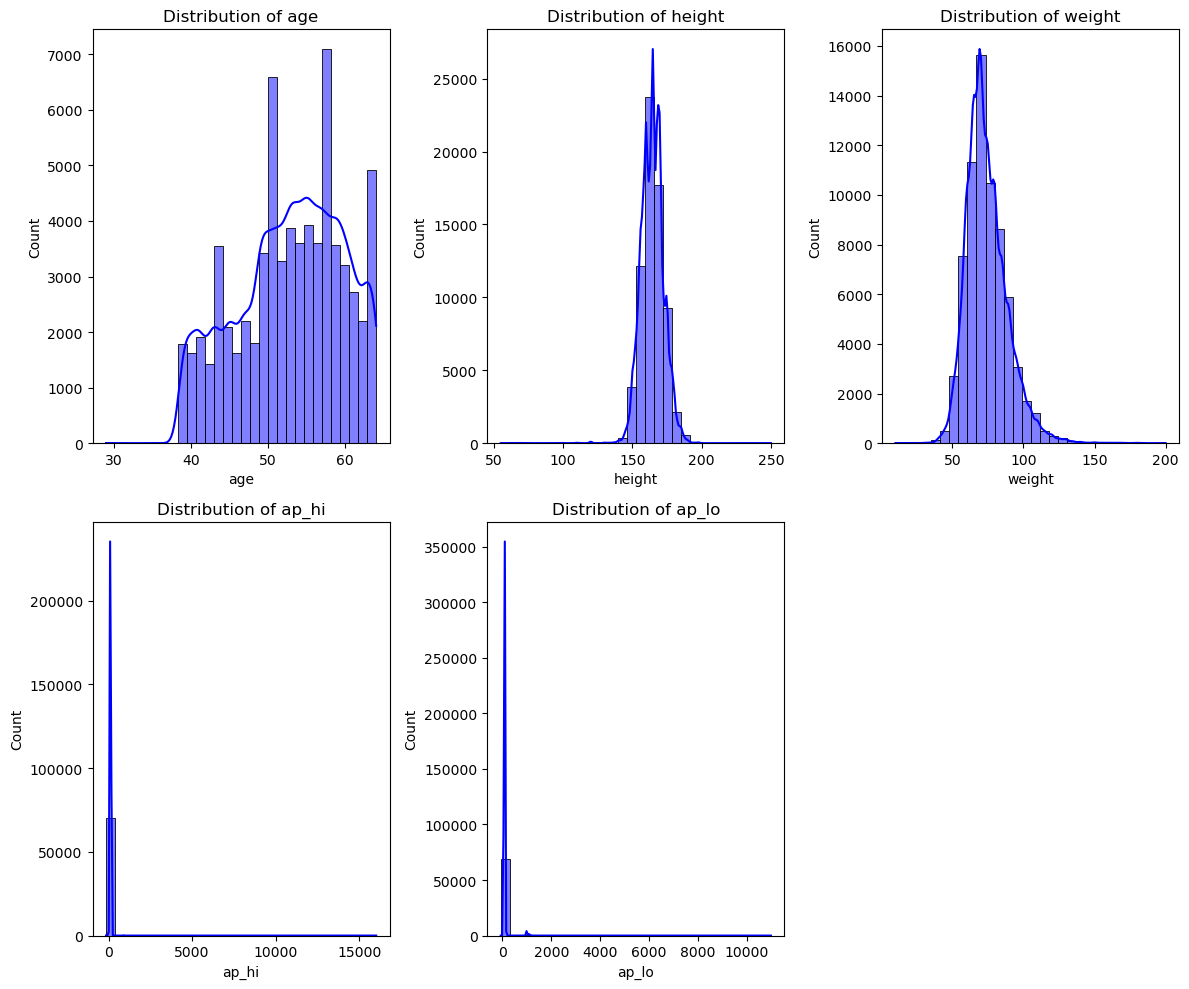

In [129]:
#Select numerical columns for analysis
numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']


#Plotting the Distribution with Histogram and KDE for each numerical column
plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig("all_distributions.png", dpi=300, bbox_inches='tight')  # Save the entire figure
print("Saved: all_distributions.png")

plt.show()

Converting the attribute **height** from centimeters to meters, for ease in **bmi** feature creation:

In [131]:
df['height']=df['height'].apply(lambda x: x/100) # Converts height to meters. For BMI calculation. 

In [132]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,1.68,62.0,110,80,1,1,0,0,1,0
1,1,55,1,1.56,85.0,140,90,3,1,0,0,1,1
2,2,51,1,1.65,64.0,130,70,3,1,0,0,0,1
3,3,48,2,1.69,82.0,150,100,1,1,0,0,1,1
4,4,47,1,1.56,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,1.68,76.0,120,80,1,1,1,0,1,0
69996,99995,61,1,1.58,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,1.83,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,1.63,72.0,135,80,1,2,0,0,0,1


In [133]:
df.nunique() #number of different values in each column.

id             70000
age               28
gender             2
height           109
weight           287
ap_hi            153
ap_lo            157
cholesterol        3
gluc               3
smoke              2
alco               2
active             2
cardio             2
dtype: int64

#  3. Data Exploration

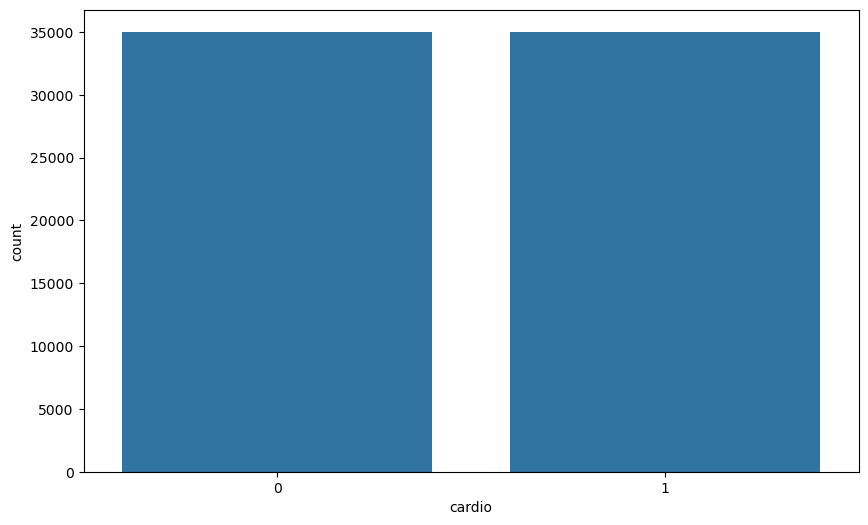

In [135]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='cardio') # How many people are sick, how many are healthy. 
plt.show()


In [136]:
df.cardio.value_counts() # Sick or not sick. Dataset is well balanced as the two categories are almost equal. 

cardio
0    35021
1    34979
Name: count, dtype: int64

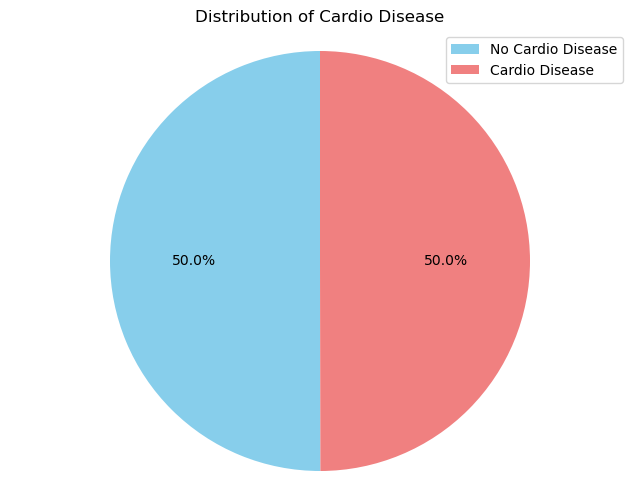

In [137]:
counts = df['cardio'].value_counts()
plt.figure(figsize=(8, 6))
labels=['No Cardio Disease', 'Cardio Disease']
plt.pie(counts, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Cardio Disease')

plt.legend(labels, loc="best")
plt.axis('equal')
plt.show()

In [138]:
Cathegorical_Columns=['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
 

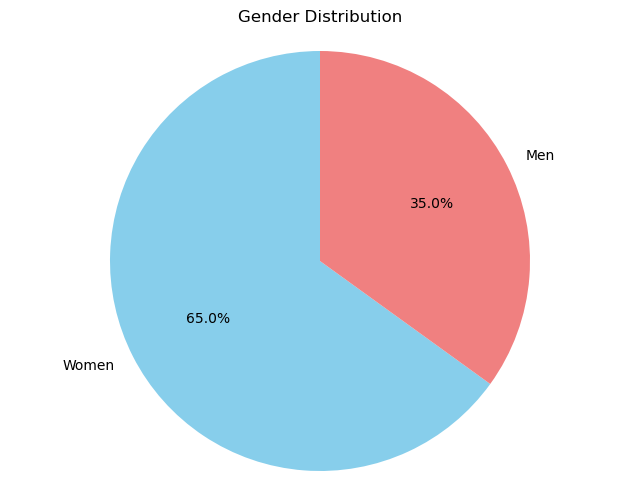

In [139]:
counts = df['gender'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(counts, labels=['Women', 'Men'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

In [140]:
counts = df['cholesterol'].value_counts()
counts



cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

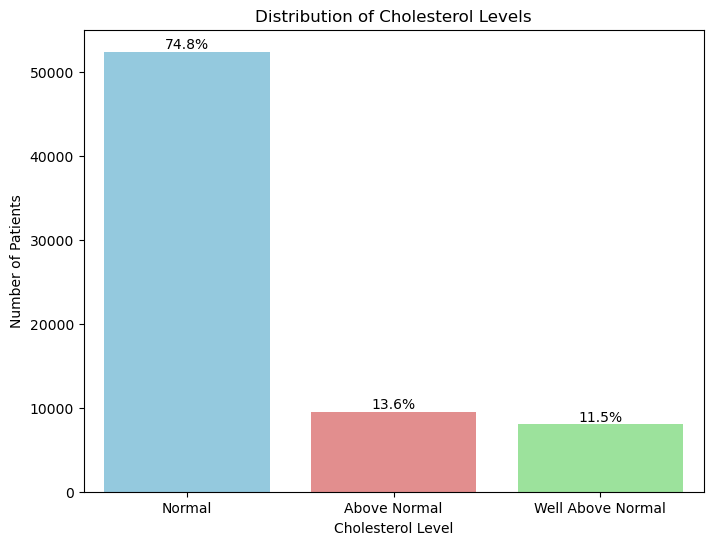

In [141]:
labels = {1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'}

plt.figure(figsize=(8, 6))
sns.countplot(x='cholesterol', data=df, order=[1, 2, 3], palette=['skyblue', 'lightcoral', 'lightgreen'])
plt.xticks([0, 1, 2], labels.values())
plt.xlabel('Cholesterol Level')
plt.ylabel('Number of Patients')
plt.title('Distribution of Cholesterol Levels')

total = len(df)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.annotate(percentage, (x, y), ha='center', va='bottom')

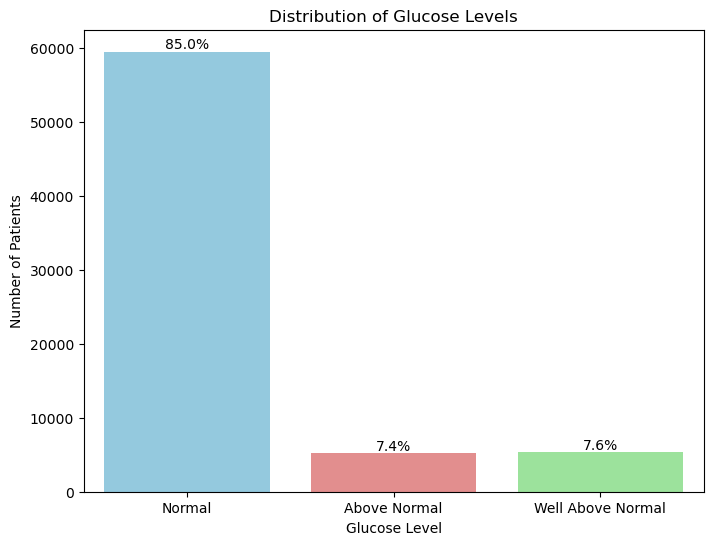

In [142]:
labels = {1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'}

plt.figure(figsize=(8, 6))
sns.countplot(x='gluc', data=df, order=[1, 2, 3], palette=['skyblue', 'lightcoral', 'lightgreen'])
plt.xticks([0, 1, 2], labels.values())
plt.xlabel('Glucose Level')
plt.ylabel('Number of Patients')
plt.title('Distribution of Glucose Levels')

total = len(df)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.annotate(percentage, (x, y), ha='center', va='bottom')

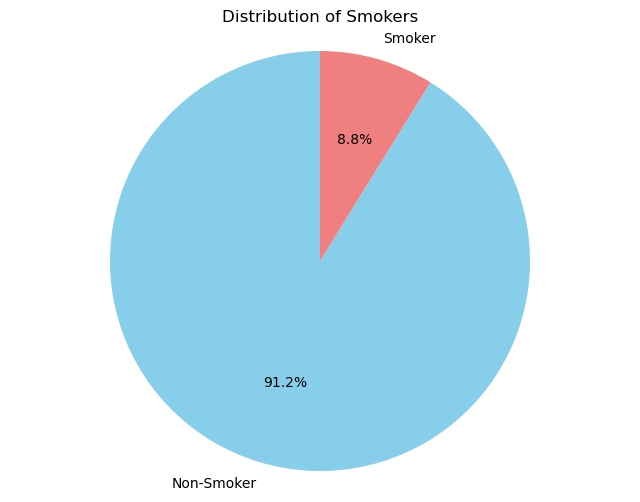

In [143]:
counts = df['smoke'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(counts, labels=['Non-Smoker', 'Smoker'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Smokers')


plt.axis('equal')
plt.show()

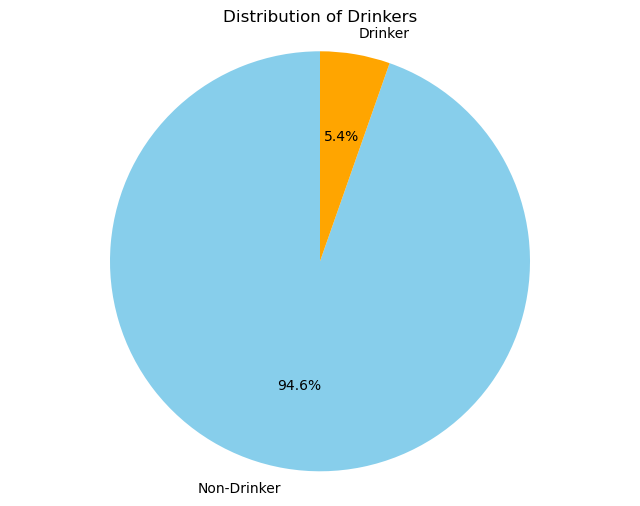

In [144]:
counts = df['alco'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(counts, labels=['Non-Drinker', 'Drinker'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'orange'])
plt.title('Distribution of Drinkers')
plt.axis('equal')
plt.show()

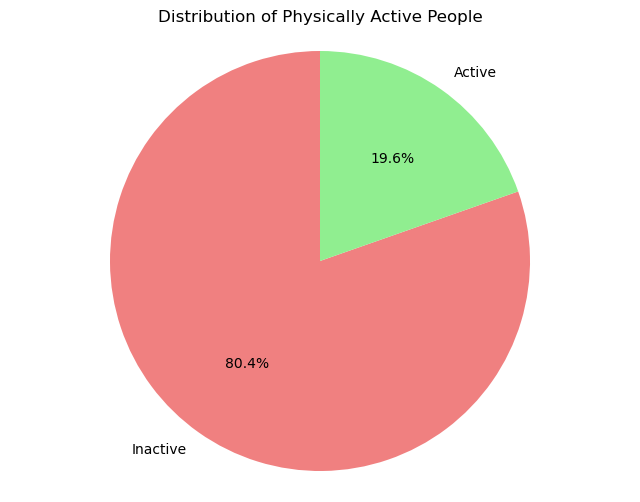

In [145]:
counts = df['active'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(counts, labels=['Inactive', 'Active'], autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightgreen'])
plt.title('Distribution of Physically Active People')
plt.axis('equal')
plt.show()

# 4. Converting Existing Attributes
Attributes like **cholesterol** and **gluc** have ordinal properties, so lets convert them to categorical:

In [147]:
df['cholesterol']=df['cholesterol'].apply(lambda x: 'normal' if x==1 else('above_normal' if x==2 else 'well_above_normal'))
df['gluc']=df['gluc'].apply(lambda x: 'normal' if x==1 else('above_normal' if x==2 else 'well_above_normal'))

In [148]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,1.68,62.0,110,80,normal,normal,0,0,1,0
1,1,55,1,1.56,85.0,140,90,well_above_normal,normal,0,0,1,1
2,2,51,1,1.65,64.0,130,70,well_above_normal,normal,0,0,0,1
3,3,48,2,1.69,82.0,150,100,normal,normal,0,0,1,1
4,4,47,1,1.56,56.0,100,60,normal,normal,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,1.68,76.0,120,80,normal,normal,1,0,1,0
69996,99995,61,1,1.58,126.0,140,90,above_normal,above_normal,0,0,1,1
69997,99996,52,2,1.83,105.0,180,90,well_above_normal,normal,0,1,0,1
69998,99998,61,1,1.63,72.0,135,80,normal,above_normal,0,0,0,1


In [149]:
num_cols=df.select_dtypes(exclude='object').columns 
cat_cols=df.select_dtypes(include='object').columns


In [150]:
num_cols

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'smoke',
       'alco', 'active', 'cardio'],
      dtype='object')

In [152]:
cat_cols

Index(['cholesterol', 'gluc'], dtype='object')

In [156]:
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,1.68,62.0,110,80,normal,normal,0,0,1,0
1,1,55,1,1.56,85.0,140,90,well_above_normal,normal,0,0,1,1
2,2,51,1,1.65,64.0,130,70,well_above_normal,normal,0,0,0,1
3,3,48,2,1.69,82.0,150,100,normal,normal,0,0,1,1
4,4,47,1,1.56,56.0,100,60,normal,normal,0,0,0,0


In [164]:
df.dtypes

id               int64
age              int32
gender           int64
height         float64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol     object
gluc            object
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

# 5. Categorical Analysis

In [166]:
df['cholesterol'].value_counts()

cholesterol
normal               52385
above_normal          9549
well_above_normal     8066
Name: count, dtype: int64

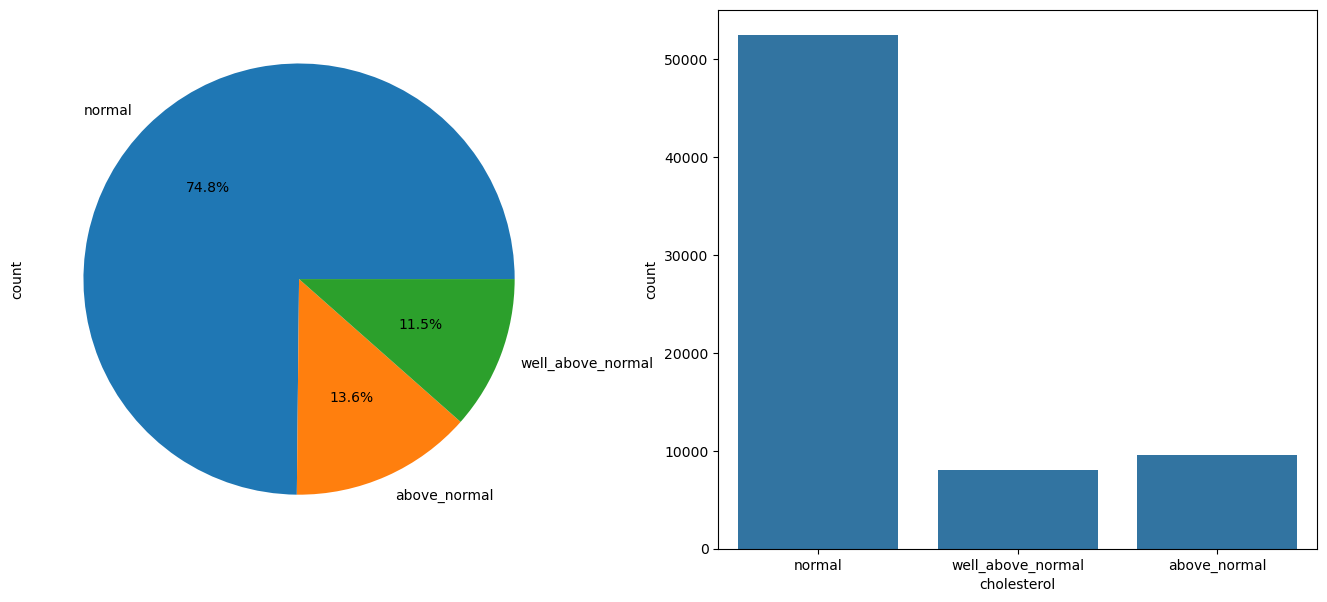

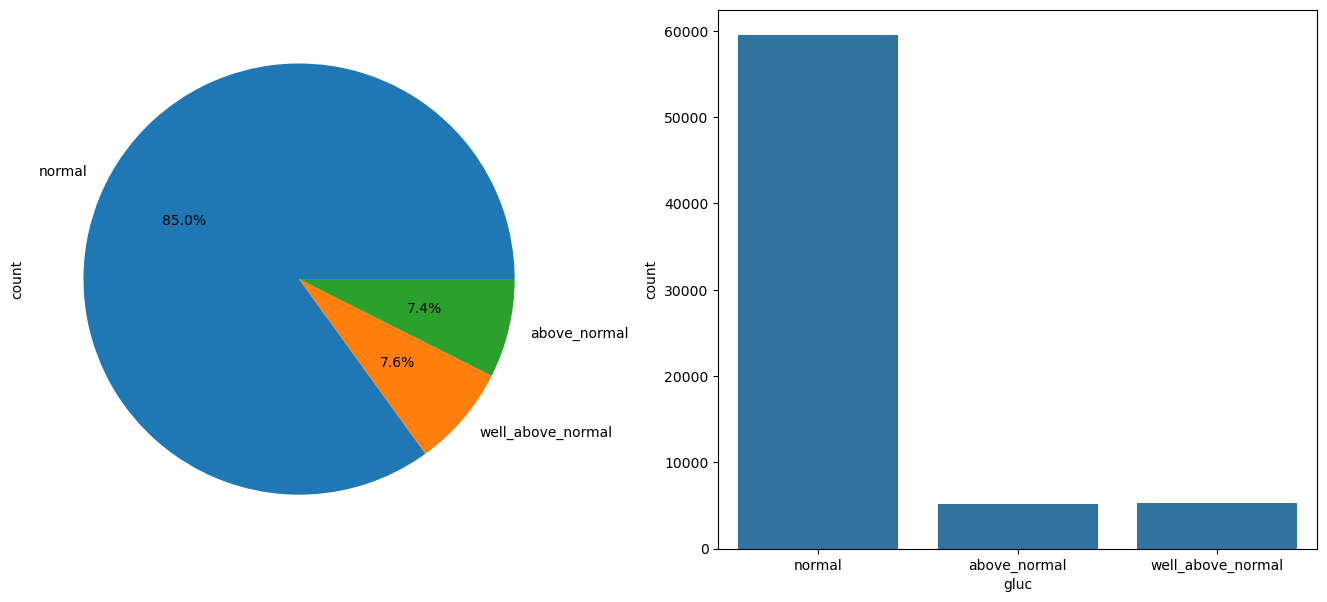

In [167]:
for i in cat_cols:
    f, ax=plt.subplots(1, 2, figsize=(17,7))
    df[i].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0])
    sns.countplot(data=df, x=i, ax=ax[1])

# 7. NUMERIC ANALYSIS

In [171]:
df[num_cols]

,id,age,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio
0,0,50,2,1.68,62.0,110,80,0,0,1,0
1,1,55,1,1.56,85.0,140,90,0,0,1,1
2,2,51,1,1.65,64.0,130,70,0,0,0,1
3,3,48,2,1.69,82.0,150,100,0,0,1,1
4,4,47,1,1.56,56.0,100,60,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,1.68,76.0,120,80,1,0,1,0
69996,99995,61,1,1.58,126.0,140,90,0,0,1,1
69997,99996,52,2,1.83,105.0,180,90,0,1,0,1
69998,99998,61,1,1.63,72.0,135,80,0,0,0,1


Image saved as: histogram_plots.png


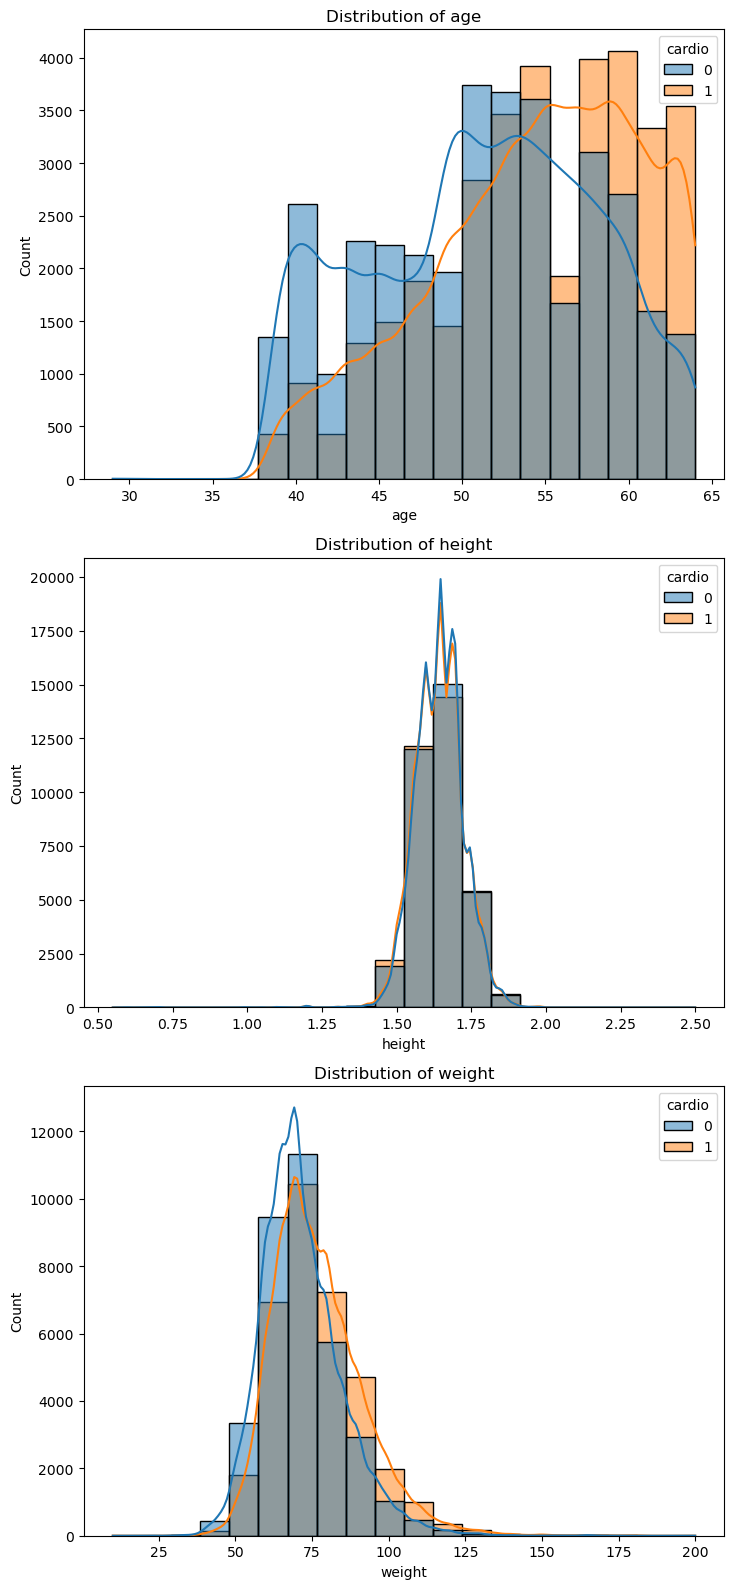

In [173]:
# Select numeric columns
num_cols = df.select_dtypes(include=['number']).columns

# Exclude categorical/binary variables and blood pressure values
binary_cols = ['id', 'gender', 'smoke', 'alco', 'active', 'cardio', 'ap_hi', 'ap_lo']
selected_cols = [col for col in num_cols if df[col].nunique() > 10 and col not in binary_cols]

# Split into two groups
left_col = selected_cols[:3]  # First 3 graphs in left column
right_col = selected_cols[3:]  # Remaining 4 graphs in right column

# Create subplots with 2 columns (3 rows for left, 4 rows for right)
fig, axes = plt.subplots(max(len(left_col), len(right_col)), 2, figsize=(14, 16))

# Plot left column (3 graphs)
for i, col in enumerate(left_col):
    sns.histplot(data=df, x=col, hue='cardio', bins=20, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}')

# Plot right column (4 graphs)
for j, col in enumerate(right_col):
    sns.histplot(data=df, x=col, hue='cardio', bins=20, kde=True, ax=axes[j, 1])
    axes[j, 1].set_title(f'Distribution of {col}')

# Hide any extra empty subplots if they exist
for i in range(len(left_col), len(axes[:, 0])):
    fig.delaxes(axes[i, 0])  # Hide empty left plots

for j in range(len(right_col), len(axes[:, 1])):
    fig.delaxes(axes[j, 1])  # Hide empty right plots

# Adjust layout for better spacing
plt.tight_layout()
image_path = "histogram_plots.png"
plt.savefig(image_path, dpi=300, bbox_inches='tight')
print(f"Image saved as: {image_path}")
plt.show()


# 8. MULTIVARIATE ANALYSIS


In [182]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

<Figure size 1000x1000 with 0 Axes>

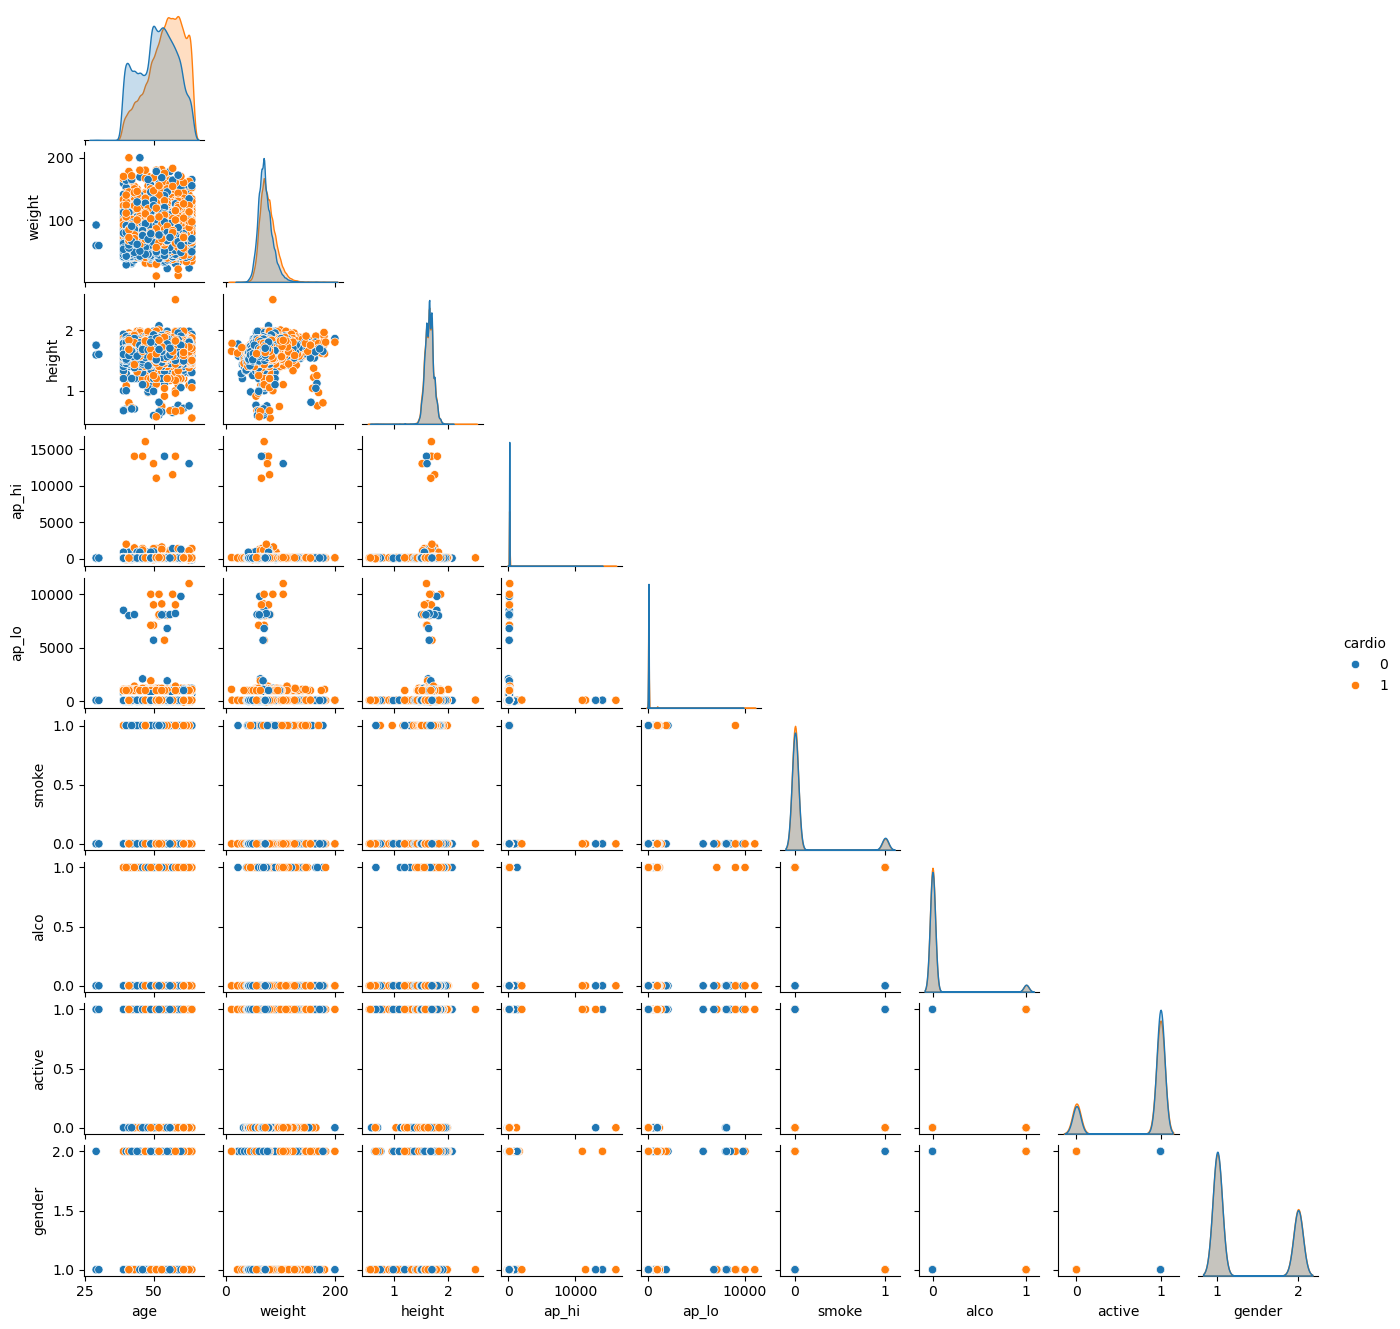

In [185]:
cols=df[['age', 'weight','height','ap_hi', 'ap_lo','cholesterol','gluc','smoke','alco','active','gender', 'cardio']]
plt.figure(figsize=(10,10))
pairplot=sns.pairplot(cols, hue='cardio', corner=True, height=1.5)
pairplot.fig.savefig("pairplot_output.png", dpi=300, bbox_inches='tight')
plt.show()

In [186]:
features=df[['age', 'gender', 'weight','height','ap_hi', 'ap_lo','cholesterol','gluc','smoke','alco','active']] 
target=df['cardio']

In [187]:
num_features=features.select_dtypes(exclude='object').columns
cat_features=features.select_dtypes(include='object').columns 

In [188]:
num_features

Index(['age', 'gender', 'weight', 'height', 'ap_hi', 'ap_lo', 'smoke', 'alco',
       'active'],
      dtype='object')

In [189]:
cat_features

Index(['cholesterol', 'gluc'], dtype='object')

In [191]:
features

,age,gender,weight,height,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,50,2,62.0,1.68,110,80,normal,normal,0,0,1
1,55,1,85.0,1.56,140,90,well_above_normal,normal,0,0,1
2,51,1,64.0,1.65,130,70,well_above_normal,normal,0,0,0
3,48,2,82.0,1.69,150,100,normal,normal,0,0,1
4,47,1,56.0,1.56,100,60,normal,normal,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69995,52,2,76.0,1.68,120,80,normal,normal,1,0,1
69996,61,1,126.0,1.58,140,90,above_normal,above_normal,0,0,1
69997,52,2,105.0,1.83,180,90,well_above_normal,normal,0,1,0
69998,61,1,72.0,1.63,135,80,normal,above_normal,0,0,0


In [193]:
target

0        0
1        1
2        1
3        1
4        0
        ..
69995    0
69996    1
69997    1
69998    1
69999    0
Name: cardio, Length: 70000, dtype: int64

In [194]:
features=pd.get_dummies(features, columns=['cholesterol', 'gluc']) #algorithm turns words to numbers. 
features

,age,gender,weight,height,ap_hi,ap_lo,smoke,alco,active,cholesterol_above_normal,cholesterol_normal,cholesterol_well_above_normal,gluc_above_normal,gluc_normal,gluc_well_above_normal
0,50,2,62.0,1.68,110,80,0,0,1,False,True,False,False,True,False
1,55,1,85.0,1.56,140,90,0,0,1,False,False,True,False,True,False
2,51,1,64.0,1.65,130,70,0,0,0,False,False,True,False,True,False
3,48,2,82.0,1.69,150,100,0,0,1,False,True,False,False,True,False
4,47,1,56.0,1.56,100,60,0,0,0,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,2,76.0,1.68,120,80,1,0,1,False,True,False,False,True,False
69996,61,1,126.0,1.58,140,90,0,0,1,True,False,False,True,False,False
69997,52,2,105.0,1.83,180,90,0,1,0,False,False,True,False,True,False
69998,61,1,72.0,1.63,135,80,0,0,0,False,True,False,True,False,False


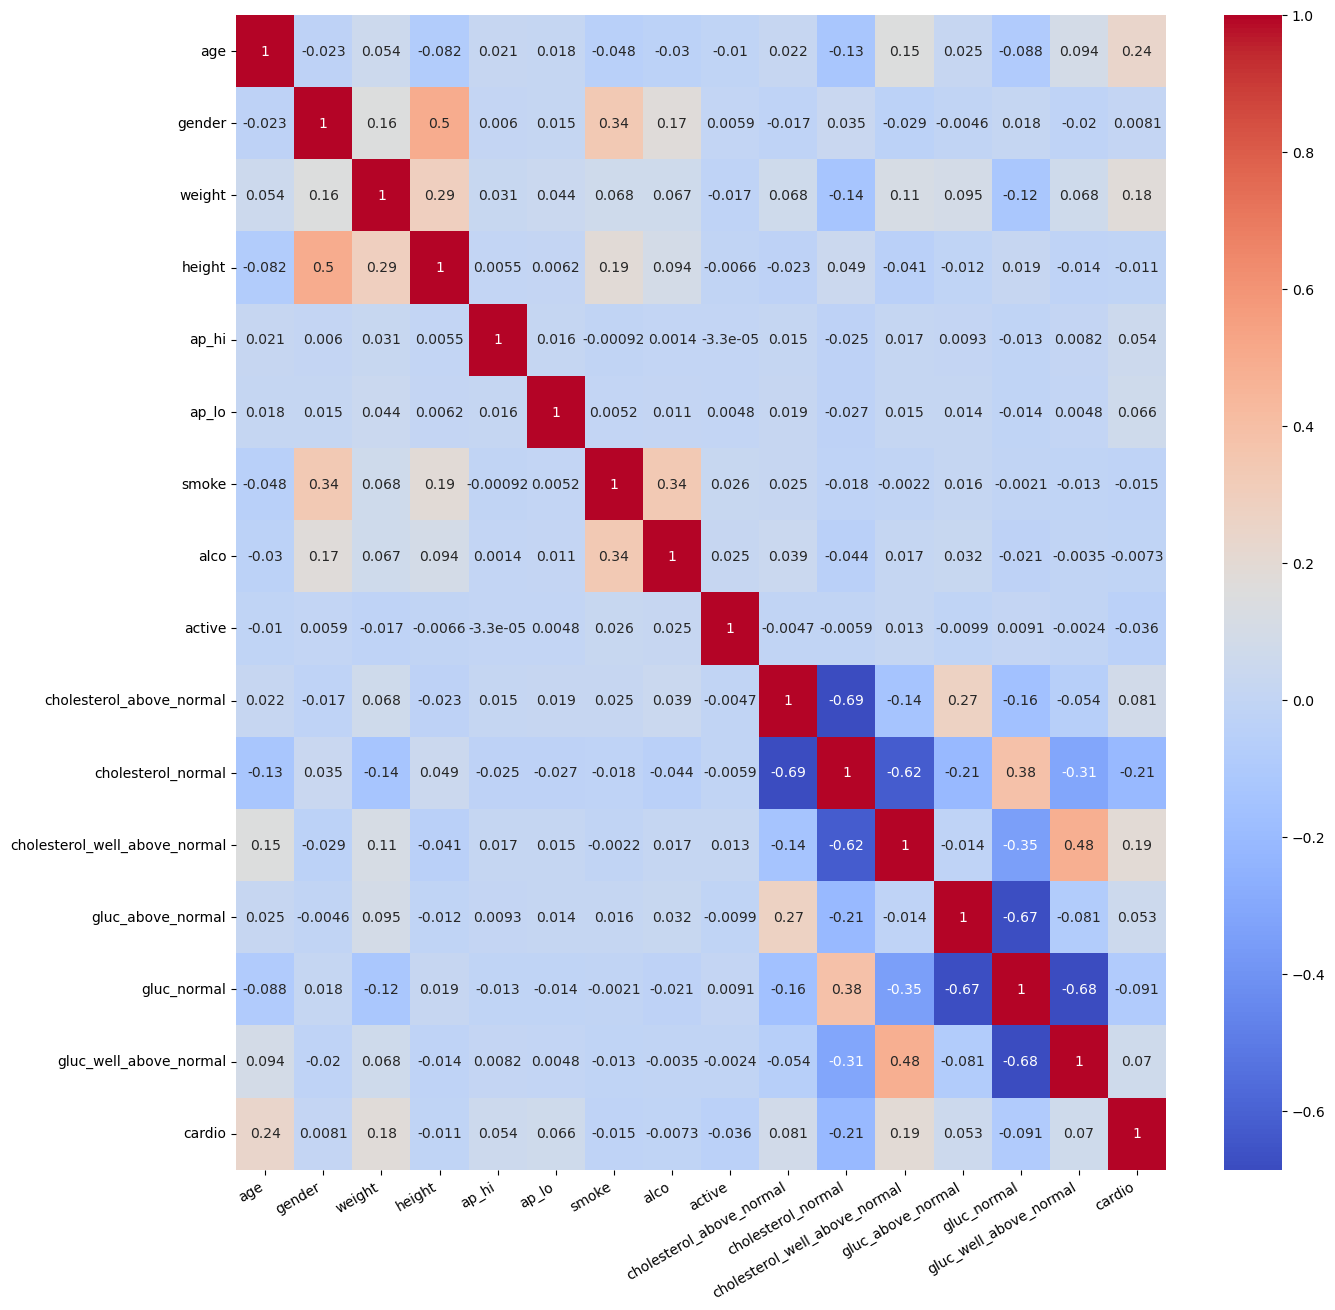

In [195]:
features['cardio'] = df['cardio']
corr=features.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.xticks(rotation=-330, ha="right", fontsize=10)
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [196]:
features = features.drop(columns=["cardio"])

# 11. Scaling Numerical Features

In [198]:
scaler=StandardScaler() # Normalization because some algorithams are sensitive to very different ranges. 

In [199]:
features[num_features]=scaler.fit_transform(features[num_features])

In [200]:
features

,age,gender,weight,height,ap_hi,ap_lo,smoke,alco,active,cholesterol_above_normal,cholesterol_normal,cholesterol_well_above_normal,gluc_above_normal,gluc_normal,gluc_well_above_normal
0,-0.419800,1.364055,-0.847873,0.443452,-0.122182,-0.088238,-0.310879,-0.238384,0.494167,False,True,False,False,True,False
1,0.319110,-0.733108,0.749831,-1.018168,0.072610,-0.035180,-0.310879,-0.238384,0.494167,False,False,True,False,True,False
2,-0.272018,-0.733108,-0.708942,0.078047,0.007679,-0.141297,-0.310879,-0.238384,-2.023607,False,False,True,False,True,False
3,-0.715364,1.364055,0.541435,0.565254,0.137541,0.017879,-0.310879,-0.238384,0.494167,False,True,False,False,True,False
4,-0.863146,-0.733108,-1.264666,-1.018168,-0.187113,-0.194356,-0.310879,-0.238384,-2.023607,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,-0.124236,1.364055,0.124642,0.443452,-0.057251,-0.088238,3.216684,-0.238384,0.494167,False,True,False,False,True,False
69996,1.205802,-0.733108,3.597913,-0.774565,0.072610,-0.035180,-0.310879,-0.238384,0.494167,True,False,False,True,False,False
69997,-0.124236,1.364055,2.139139,2.270477,0.332333,-0.035180,-0.310879,4.194906,-2.023607,False,False,True,False,True,False
69998,1.205802,-0.733108,-0.153219,-0.165556,0.040145,-0.088238,-0.310879,-0.238384,-2.023607,False,True,False,True,False,False


# 13. MODELING

In [204]:
x_train, x_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

In [205]:

# Logistic Regression
lr = LogisticRegression(random_state=42)

# Random Forest 
rf = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=20)


In [206]:
lr.fit(x_train, y_train)
rf.fit(x_train, y_train)


lr_pred = lr.predict(x_test)  
rf_pred = rf.predict(x_test)  


In [207]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_confusion = confusion_matrix(y_test, lr_pred)
lr_classification_report_str = classification_report(y_test, lr_pred)



rf_accuracy = accuracy_score(y_test, rf_pred)
rf_confusion = confusion_matrix(y_test, rf_pred)
rf_classification_report_str = classification_report(y_test, rf_pred)



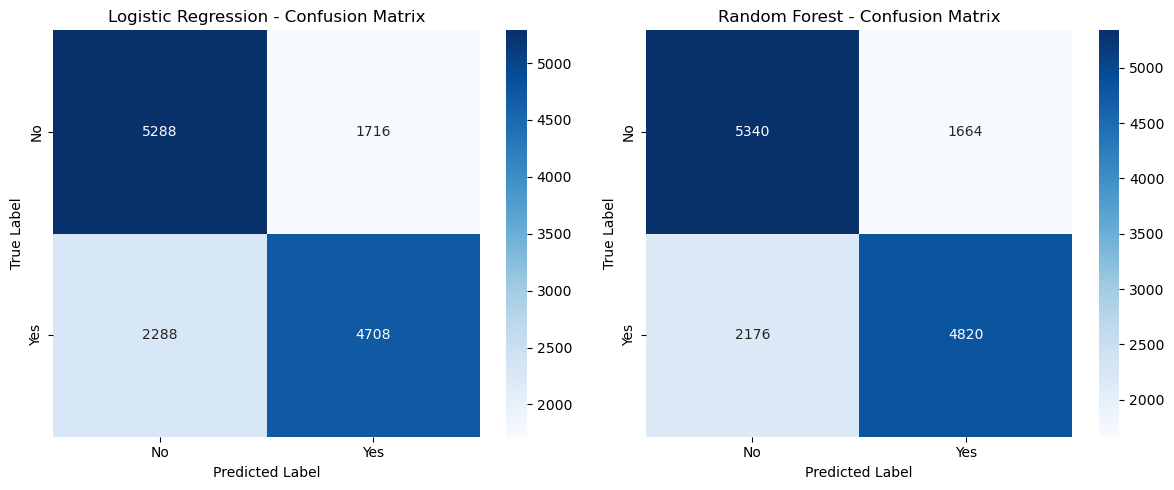

In [208]:
# Compute confusion matrices
lr_confusion = confusion_matrix(y_test, lr_pred)
rf_confusion = confusion_matrix(y_test, rf_pred)

# Define model names and corresponding confusion matrices
models = {
    "Logistic Regression": lr_confusion,
    "Random Forest": rf_confusion
}

# Create confusion matrices for both models
plt.figure(figsize=(12, 5))
for i, (model_name, conf_matrix) in enumerate(models.items(), 1):
    plt.subplot(1, 2, i)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()

Logistic Regression Results:
Accuracy: 0.714
Confusion Matrix:
[[5288 1716]
 [2288 4708]]
Classification Report:
              precision    recall  f1-score   support

           0      0.698     0.755     0.725      7004
           1      0.733     0.673     0.702      6996

    accuracy                          0.714     14000
   macro avg      0.715     0.714     0.714     14000
weighted avg      0.715     0.714     0.714     14000

Random Forest Classifier Results: 
Accuracy: 0.726
Confusion Matrix:
[[5340 1664]
 [2176 4820]]
Classification Report:
              precision    recall  f1-score   support

           0      0.710     0.762     0.736      7004
           1      0.743     0.689     0.715      6996

    accuracy                          0.726     14000
   macro avg      0.727     0.726     0.725     14000
weighted avg      0.727     0.726     0.725     14000



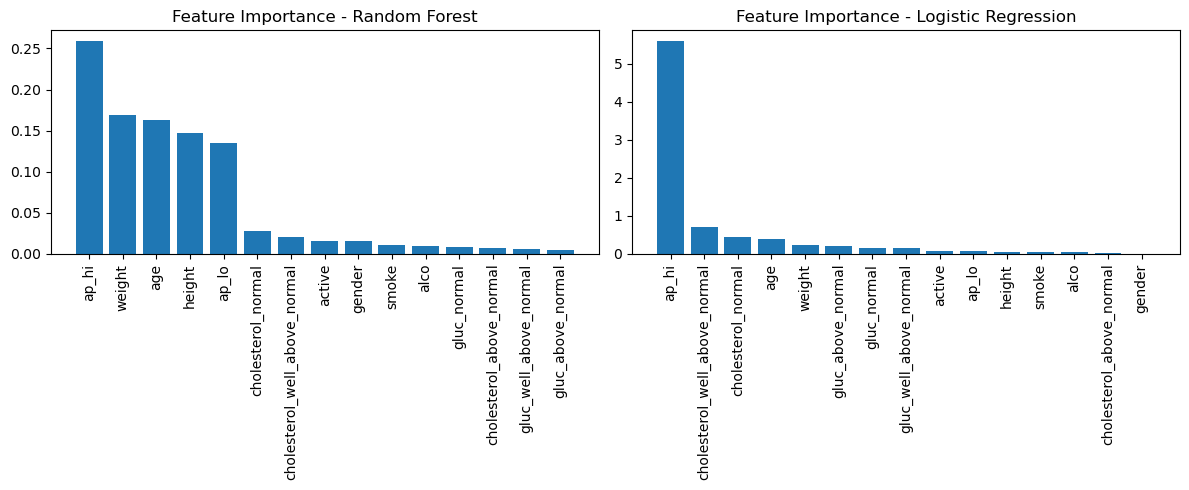

In [209]:
print("Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.3f}")  # <- round to 3 decimals
print("Confusion Matrix:")
print(lr_confusion)
print("Classification Report:")
lr_classification_report_str = classification_report(y_test, lr_pred, digits=3)
print(lr_classification_report_str)




print('Random Forest Classifier Results: ')
print(f"Accuracy: {rf_accuracy:.3f}")
print("Confusion Matrix:")
print(rf_confusion)
print("Classification Report:")
rf_classification_report_str = classification_report(y_test, rf_pred, digits=3)
print(rf_classification_report_str)

# Get importance
rf_importance = rf.feature_importances_
lr_importance = np.abs(lr.coef_[0])  # absolute value of coefficients

# Prepare plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes.ravel()

models_with_importance = {
    'Random Forest': rf_importance,
    'Logistic Regression': lr_importance
}

for i, (name, importance) in enumerate(models_with_importance.items()):
    sorted_idx = np.argsort(importance)[::-1]
    ax[i].bar(range(len(importance)), importance[sorted_idx], align='center')
    ax[i].set_xticks(range(len(importance)))
    ax[i].set_xticklabels(np.array(x_train.columns)[sorted_idx], rotation=90)
    ax[i].set_title(f'Feature Importance - {name}')

plt.tight_layout()
plt.show()



438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step

XGBoost Metrics:
Accuracy: 0.7314
Confusion Matrix:
[[5379 1625]
 [2135 4861]]
Classification Report:
              precision    recall  f1-score   support

           0      0.716     0.768     0.741      7004
           1      0.749     0.695     0.721      6996

    accuracy                          0.731     14000
   macro avg      0.733     0.731     0.731     14000
weighted avg      0.733     0.731     0.731     14000


CatBoost Metrics:
Accuracy: 0.7323
Confusion Matrix:
[[5377 1627]
 [2121 4875]]
Classification Report:
              precision    recall  f1-score   support

           0      0.717     0.768     0.742      7004
           1      0.750     0.697     0.722      6996

    accuracy                          0.732     14000
   macro avg      0.733     0.732     0.732     14000
weighted avg      0.733     0.732     0.732     14000


Neural Network Metrics:
Accuracy: 0.7216
Confusion Matrix:
[[4610 2394]
 [1503 5493]]
Classific

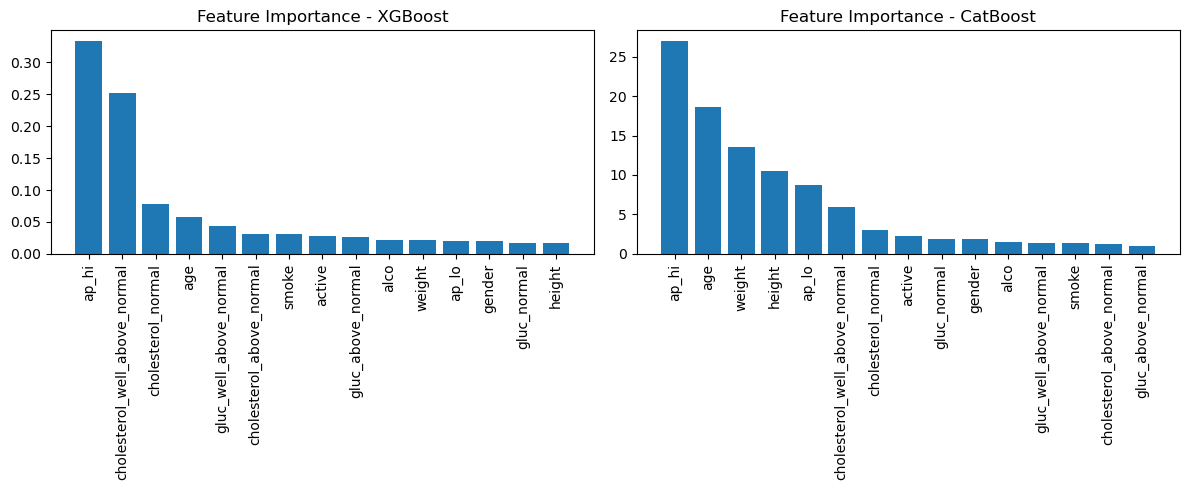

In [210]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance  # Permutation importance tool
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Initialize XGBoost and CatBoost models
xgb = XGBClassifier(random_state=42)
cat = CatBoostClassifier(random_state=42)

# Define a simple Artificial Neural Network using Keras (ANN)
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),  # First hidden layer with 64 neurons
    Dropout(0.3),                                                    # Dropout to reduce overfitting
    Dense(32, activation='relu'),                                    # Second hidden layer with 32 neurons
    Dense(1, activation='sigmoid')                                   # Output layer for binary classification
])

# Compile ANN with Adam optimizer and binary crossentropy loss
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train all models
xgb.fit(x_train, y_train)
cat.fit(x_train, y_train, verbose=0)
model.fit(x_train, y_train, epochs=50, batch_size=32, verbose=0, validation_data=(x_test, y_test))

#  Make Predictions
xgb_pred = xgb.predict(x_test)
cat_pred = cat.predict(x_test)
ann_pred = (model.predict(x_test) > 0.4).astype(int)  # ANN outputs probabilities, so threshold at 0.4

# Evaluate all models
models = {'XGBoost': xgb_pred, 'CatBoost': cat_pred, 'Neural Network': ann_pred.flatten()}
for name, pred in models.items():
    print(f'\n{name} Metrics:')
    print(f'Accuracy: {accuracy_score(y_test, pred):.4f}')
    print(f'Confusion Matrix:\n{confusion_matrix(y_test, pred)}')
    print(f'Classification Report:\n{classification_report(y_test, pred, digits=3)}')

# Plot Tree-Based Feature Importance (XGBoost & CatBoost only)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes.ravel()

models_with_importance = {
    'XGBoost': xgb.feature_importances_,
    'CatBoost': cat.get_feature_importance()
}

for i, (name, importance) in enumerate(models_with_importance.items()):
    sorted_idx = np.argsort(importance)[::-1]
    ax[i].bar(range(len(importance)), importance[sorted_idx], align='center')
    ax[i].set_xticks(range(len(importance)))
    ax[i].set_xticklabels(np.array(x_train.columns)[sorted_idx], rotation=90)
    ax[i].set_title(f'Feature Importance - {name}')

plt.tight_layout()
plt.show()




In [125]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Define five different neural network models
def build_model_1(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_model_2(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=RMSprop(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_model_3(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_model_4(input_dim):
    model = Sequential([
        Dense(128, activation='tanh', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(64, activation='tanh'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_model_5(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=RMSprop(learning_rate=0.0002), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define the models
models = {
    'Model 1': build_model_1(x_train.shape[1]),
    'Model 2': build_model_2(x_train.shape[1]),
    'Model 3': build_model_3(x_train.shape[1]),
    'Model 4': build_model_4(x_train.shape[1]),
    'Model 5': build_model_5(x_train.shape[1])
}

# Train models and evaluate them
results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(x_train, y_train, epochs=50, batch_size=32, verbose=0, validation_data=(x_test, y_test))
    pred = (model.predict(x_test) > 0.4).astype(int)
    acc = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)
    report = classification_report(y_test, pred,digits=3)
    
    results[name] = {'Accuracy': acc, 'Confusion Matrix': cm, 'Classification Report': report}

# Display results
for name, res in results.items():
    print(f'\n{name} Metrics:')
    print(f'Accuracy: {res["Accuracy"]:.4f}')
    print(f'Confusion Matrix:\n{res["Confusion Matrix"]}')
    print(f'Classification Report:\n{res["Classification Report"]}')




Training Model 1...
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
Training Model 2...
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Training Model 3...
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Training Model 4...
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Training Model 5...
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Model 1 Metrics:
Accuracy: 0.7241
Confusion Matrix:
[[4675 2329]
 [1534 5462]]
Classification Report:
              precision    recall  f1-score   support

           0      0.753     0.667     0.708      7004
           1      0.701     0.781     0.739      6996

    accuracy                          0.724     14000
   macro avg      0.727     0.724     0.723     14000
weighted avg      0.727     0.724     0.723     14000


Model 2 Metrics:
Accuracy: 0.7087
Confusion Matrix:
[[4204 2800]
 [1278 5718]]
Classification Report:
              precision    recall  f1-score   support

           0      0.767     0.600     0.673      7004
           1      0.671     0.817     0.737      


 Calculating Permutation Feature Importance for the Neural Network


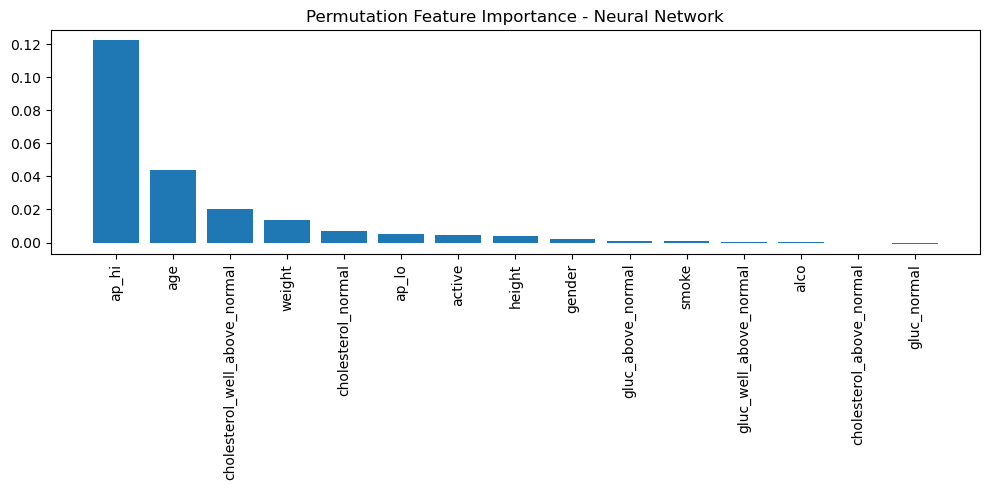

In [239]:
from sklearn.base import BaseEstimator, ClassifierMixin

class KerasANNWrapper(BaseEstimator, ClassifierMixin):
    """Makes a Keras model compatible with sklearn tools like permutation_importance."""
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])  # Required by scikit-learn scoring

    def fit(self, X, y):
        return self  # Already trained externally

    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.4).astype(int).flatten()
        
 # Wrap the trained ANN model       
best_model = models['Model 4']
wrapped_ann = KerasANNWrapper(best_model)


# Calculate permutation importance on the test set
print("\n Calculating Permutation Feature Importance for the Neural Network")
perm_result = permutation_importance(wrapped_ann, x_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')

# Plot Permutation Feature Importance for ANN
sorted_idx = perm_result.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(sorted_idx)), perm_result.importances_mean[sorted_idx])
plt.xticks(range(len(sorted_idx)), np.array(x_train.columns)[sorted_idx], rotation=90)
plt.title("Permutation Feature Importance - Neural Network")
plt.tight_layout()
plt.show()


# Feature Selection


In [243]:

# Define features to drop based on consistent low importance across models
cols_to_drop = [
    'gluc_normal',
    'gluc_above_normal',
    'gluc_well_above_normal',
    'smoke',
    'alco',
    'gender'
]

# Drop them from the feature set
features_remaining = features.drop(columns=cols_to_drop)
features_remaining

,age,weight,height,ap_hi,ap_lo,active,cholesterol_above_normal,cholesterol_normal,cholesterol_well_above_normal
0,-0.419800,-0.847873,0.443452,-0.122182,-0.088238,0.494167,False,True,False
1,0.319110,0.749831,-1.018168,0.072610,-0.035180,0.494167,False,False,True
2,-0.272018,-0.708942,0.078047,0.007679,-0.141297,-2.023607,False,False,True
3,-0.715364,0.541435,0.565254,0.137541,0.017879,0.494167,False,True,False
4,-0.863146,-1.264666,-1.018168,-0.187113,-0.194356,-2.023607,False,True,False
...,...,...,...,...,...,...,...,...,...
69995,-0.124236,0.124642,0.443452,-0.057251,-0.088238,0.494167,False,True,False
69996,1.205802,3.597913,-0.774565,0.072610,-0.035180,0.494167,True,False,False
69997,-0.124236,2.139139,2.270477,0.332333,-0.035180,-2.023607,False,False,True
69998,1.205802,-0.153219,-0.165556,0.040145,-0.088238,-2.023607,False,True,False


 Saved split — reproducibility preserved 


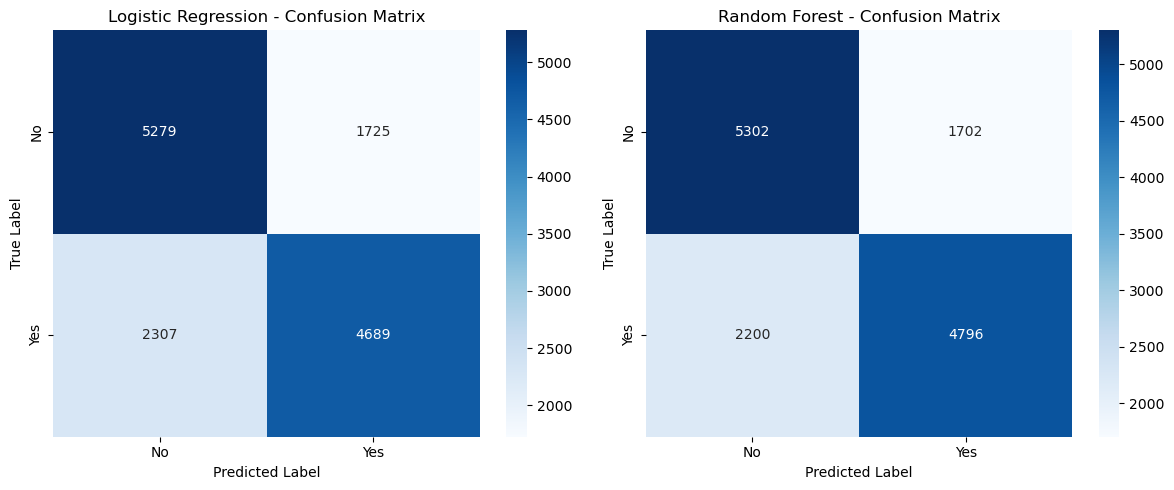

Logistic Regression Results:
Accuracy: 0.712
Confusion Matrix:
[[5279 1725]
 [2307 4689]]
Classification Report:
              precision    recall  f1-score   support

           0      0.696     0.754     0.724      7004
           1      0.731     0.670     0.699      6996

    accuracy                          0.712     14000
   macro avg      0.713     0.712     0.711     14000
weighted avg      0.713     0.712     0.711     14000

Random Forest Classifier Results: 
Accuracy: 0.721
Confusion Matrix:
[[5302 1702]
 [2200 4796]]
Classification Report:
              precision    recall  f1-score   support

           0      0.707     0.757     0.731      7004
           1      0.738     0.686     0.711      6996

    accuracy                          0.721     14000
   macro avg      0.722     0.721     0.721     14000
weighted avg      0.722     0.721     0.721     14000


XGBoost Metrics:
Accuracy: 0.7313
Confusion Matrix:
[[5376 1628]
 [2134 4862]]
Classification Report:
           

In [245]:
x_train, x_test, y_train, y_test = train_test_split(
    features_remaining, target,
    test_size=0.20,
    random_state=42,
    stratify=target
)
import joblib
joblib.dump((x_train, x_test, y_train, y_test), "train_test_split.pkl")
print(" Saved split — reproducibility preserved ")
# Logistic Regression
lr = LogisticRegression(random_state=42)

# Random Forest 
rf = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=20)
lr.fit(x_train, y_train)
rf.fit(x_train, y_train)


lr_pred = lr.predict(x_test)  
rf_pred = rf.predict(x_test) 
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_confusion = confusion_matrix(y_test, lr_pred)
lr_classification_report_str = classification_report(y_test, lr_pred)



rf_accuracy = accuracy_score(y_test, rf_pred)
rf_confusion = confusion_matrix(y_test, rf_pred)
rf_classification_report_str = classification_report(y_test, rf_pred)
# Compute confusion matrices
lr_confusion = confusion_matrix(y_test, lr_pred)
rf_confusion = confusion_matrix(y_test, rf_pred)

# Define model names and corresponding confusion matrices
models = {
    "Logistic Regression": lr_confusion,
    "Random Forest": rf_confusion
}

# Create confusion matrices for both models
plt.figure(figsize=(12, 5))
for i, (model_name, conf_matrix) in enumerate(models.items(), 1):
    plt.subplot(1, 2, i)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()

print("Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.3f}")  # <- round to 3 decimals
print("Confusion Matrix:")
print(lr_confusion)
print("Classification Report:")
lr_classification_report_str = classification_report(y_test, lr_pred, digits=3)
print(lr_classification_report_str)




print('Random Forest Classifier Results: ')
print(f"Accuracy: {rf_accuracy:.3f}")
print("Confusion Matrix:")
print(rf_confusion)
print("Classification Report:")
rf_classification_report_str = classification_report(y_test, rf_pred, digits=3)
print(rf_classification_report_str)

# Initialize XGBoost and CatBoost models
xgb = XGBClassifier(random_state=42)
cat = CatBoostClassifier(random_state=42)



# Train all models
xgb.fit(x_train, y_train)
cat.fit(x_train, y_train, verbose=0)


#  Make Predictions
xgb_pred = xgb.predict(x_test)
cat_pred = cat.predict(x_test)


# Evaluate all models
models = {'XGBoost': xgb_pred, 'CatBoost': cat_pred}
for name, pred in models.items():
    print(f'\n{name} Metrics:')
    print(f'Accuracy: {accuracy_score(y_test, pred):.4f}')
    print(f'Confusion Matrix:\n{confusion_matrix(y_test, pred)}')
    print(f'Classification Report:\n{classification_report(y_test, pred, digits=3)}')




# Define neural network model


def build_model_4(input_dim):
    model = Sequential([
        Dense(128, activation='tanh', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(64, activation='tanh'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])
    return model


# Define the model
models = {
   
    'Model 4': build_model_4(x_train.shape[1])
}

# Train models and evaluate them
results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(x_train, y_train, epochs=50, batch_size=32, verbose=0, validation_data=(x_test, y_test))
    pred = (model.predict(x_test) > 0.4).astype(int)
    acc = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)
    report = classification_report(y_test, pred,digits=3)
    
    results[name] = {'Accuracy': acc, 'Confusion Matrix': cm, 'Classification Report': report}

# Display results
for name, res in results.items():
    print(f'\n{name} Metrics:')
    print(f'Accuracy: {res["Accuracy"]:.4f}')
    print(f'Confusion Matrix:\n{res["Confusion Matrix"]}')
    print(f'Classification Report:\n{res["Classification Report"]}')





# Feature Engineering

In [247]:
features_eng = features_remaining.copy()
# Feature Engineering for Cardiovascular Disease Prediction

import numpy as np

# 1. Body Mass Index (BMI)
features_eng["BMI"] = features_eng["weight"] / (features_eng["height"]**2 + 1e-5)

# 2. Pulse Pressure (PP): Systolic - Diastolic
features_eng["pulse_pressure"] = features_eng["ap_hi"] - features_eng["ap_lo"]

# 3. Mean Arterial Pressure (MAP): diastolic + 1/3 * PP
features_eng["MAP"] = features_eng["ap_lo"] + (features_eng["pulse_pressure"] / 3)

# 4. Systolic/Diastolic Ratio
features_eng["sys_dia_ratio"] = features_eng["ap_hi"] / (features_eng["ap_lo"] + 1e-5)

# 5. Cholesterol Index (0 = normal, 1 = above normal, 2 = well above)
features_eng["cholesterol_index"] = (
    features_eng["cholesterol_above_normal"].astype(int) +
    2 * features_eng["cholesterol_well_above_normal"].astype(int)
)

# 6. Obesity Flag (BMI >= 30)
features_eng["obese"] = (features_eng["BMI"] >= 30).astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    features_eng, target,
    test_size=0.20,
    random_state=42,
    stratify=target
)
import joblib
joblib.dump((x_train, x_test, y_train, y_test), "train_test_split_with_feature_eng.pkl")
print("✅ Saved new train/test split with engineered features: 'train_test_split_with_feature_eng.pkl'")

✅ Saved new train/test split with engineered features: 'train_test_split_with_feature_eng.pkl'


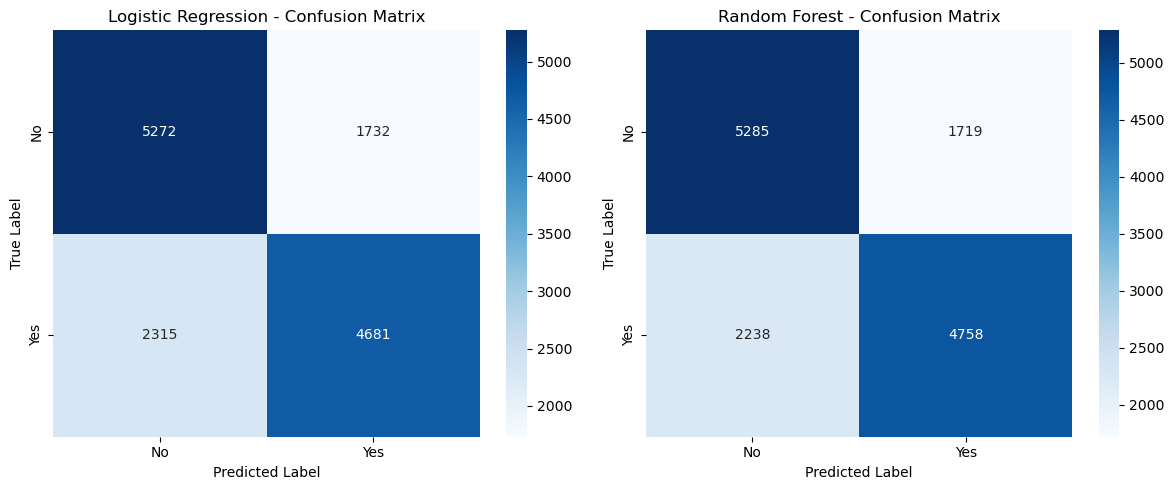

Logistic Regression Results:
Accuracy: 0.711
Confusion Matrix:
[[5272 1732]
 [2315 4681]]
Classification Report:
              precision    recall  f1-score   support

           0      0.695     0.753     0.723      7004
           1      0.730     0.669     0.698      6996

    accuracy                          0.711     14000
   macro avg      0.712     0.711     0.710     14000
weighted avg      0.712     0.711     0.710     14000

Random Forest Classifier Results: 
Accuracy: 0.717
Confusion Matrix:
[[5285 1719]
 [2238 4758]]
Classification Report:
              precision    recall  f1-score   support

           0      0.703     0.755     0.728      7004
           1      0.735     0.680     0.706      6996

    accuracy                          0.717     14000
   macro avg      0.719     0.717     0.717     14000
weighted avg      0.719     0.717     0.717     14000


XGBoost Metrics:
Accuracy: 0.7259
Confusion Matrix:
[[5328 1676]
 [2162 4834]]
Classification Report:
           

In [249]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Logistic Regression
lr = LogisticRegression(random_state=42)

# Random Forest 
rf = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=20)
lr.fit(x_train, y_train)
rf.fit(x_train, y_train)


lr_pred = lr.predict(x_test)  
rf_pred = rf.predict(x_test) 
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_confusion = confusion_matrix(y_test, lr_pred)
lr_classification_report_str = classification_report(y_test, lr_pred)



rf_accuracy = accuracy_score(y_test, rf_pred)
rf_confusion = confusion_matrix(y_test, rf_pred)
rf_classification_report_str = classification_report(y_test, rf_pred)
# Compute confusion matrices
lr_confusion = confusion_matrix(y_test, lr_pred)
rf_confusion = confusion_matrix(y_test, rf_pred)

# Define model names and corresponding confusion matrices
models = {
    "Logistic Regression": lr_confusion,
    "Random Forest": rf_confusion
}

# Create confusion matrices for both models
plt.figure(figsize=(12, 5))
for i, (model_name, conf_matrix) in enumerate(models.items(), 1):
    plt.subplot(1, 2, i)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()

print("Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.3f}")  # <- round to 3 decimals
print("Confusion Matrix:")
print(lr_confusion)
print("Classification Report:")
lr_classification_report_str = classification_report(y_test, lr_pred, digits=3)
print(lr_classification_report_str)




print('Random Forest Classifier Results: ')
print(f"Accuracy: {rf_accuracy:.3f}")
print("Confusion Matrix:")
print(rf_confusion)
print("Classification Report:")
rf_classification_report_str = classification_report(y_test, rf_pred, digits=3)
print(rf_classification_report_str)

# Initialize XGBoost and CatBoost models
xgb = XGBClassifier(random_state=42)
cat = CatBoostClassifier(random_state=42)



# Train all models
xgb.fit(x_train, y_train)
cat.fit(x_train, y_train, verbose=0)


#  Make Predictions
xgb_pred = xgb.predict(x_test)
cat_pred = cat.predict(x_test)


# Evaluate all models
models = {'XGBoost': xgb_pred, 'CatBoost': cat_pred}
for name, pred in models.items():
    print(f'\n{name} Metrics:')
    print(f'Accuracy: {accuracy_score(y_test, pred):.4f}')
    print(f'Confusion Matrix:\n{confusion_matrix(y_test, pred)}')
    print(f'Classification Report:\n{classification_report(y_test, pred, digits=3)}')




# Define neural network model



def build_model_4(input_dim):
    model = Sequential([
        Dense(128, activation='tanh', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(64, activation='tanh'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])
    return model
    
# Define the model
models = {
   
    'Model 4': build_model_4(x_train.shape[1])
}

# Train models and evaluate them
results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(x_train, y_train, epochs=50, batch_size=32, verbose=0, validation_data=(x_test, y_test))
    pred = (model.predict(x_test) > 0.4).astype(int)
    acc = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)
    report = classification_report(y_test, pred,digits=3)
    
    results[name] = {'Accuracy': acc, 'Confusion Matrix': cm, 'Classification Report': report}

# Display results
for name, res in results.items():
    print(f'\n{name} Metrics:')
    print(f'Accuracy: {res["Accuracy"]:.4f}')
    print(f'Confusion Matrix:\n{res["Confusion Matrix"]}')
    print(f'Classification Report:\n{res["Classification Report"]}')

# Hyperparameter Tuning


Tuning Logistic Regression...
Fitting 10 folds for each of 20 candidates, totalling 200 fits

Logistic Regression - Best Hyperparameters:
{'C': 4.838160165372797, 'max_iter': 300, 'penalty': 'l2', 'solver': 'liblinear'}
Test Set Recall: 0.6681
[[5282 1722]
 [2322 4674]]
              precision    recall  f1-score   support

           0      0.695     0.754     0.723      7004
           1      0.731     0.668     0.698      6996

    accuracy                          0.711     14000
   macro avg      0.713     0.711     0.711     14000
weighted avg      0.713     0.711     0.711     14000


Logistic Regression CV Mean Accuracy: 0.7195, Std Dev: 0.0004


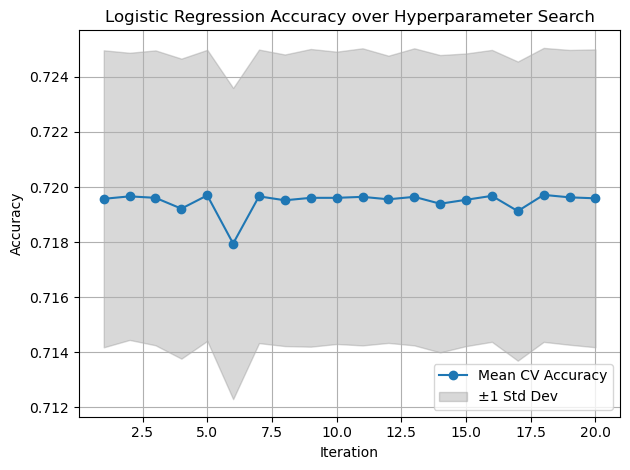


Tuning Random Forest...
Fitting 10 folds for each of 20 candidates, totalling 200 fits

Random Forest - Best Hyperparameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 12, 'bootstrap': True}
Test Set Recall: 0.6781
[[5459 1545]
 [2252 4744]]
              precision    recall  f1-score   support

           0      0.708     0.779     0.742      7004
           1      0.754     0.678     0.714      6996

    accuracy                          0.729     14000
   macro avg      0.731     0.729     0.728     14000
weighted avg      0.731     0.729     0.728     14000


Random Forest CV Mean Accuracy: 0.7323, Std Dev: 0.0008


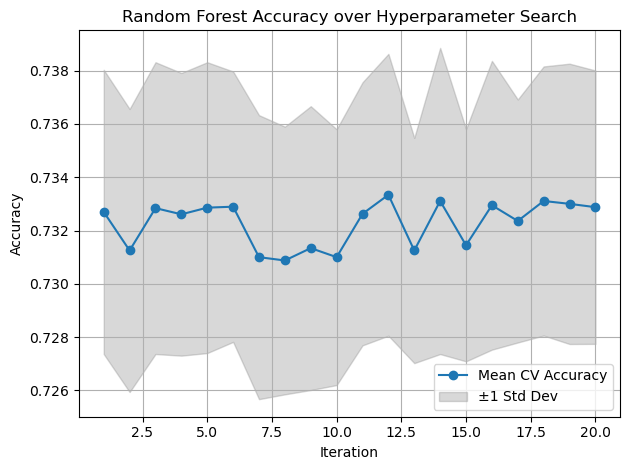


Tuning CatBoost...
Fitting 10 folds for each of 25 candidates, totalling 250 fits

CatBoost - Best Hyperparameters:
{'depth': 4, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.05934434683002587}
Test Set Recall: 0.6965
[[5390 1614]
 [2123 4873]]
              precision    recall  f1-score   support

           0      0.717     0.770     0.743      7004
           1      0.751     0.697     0.723      6996

    accuracy                          0.733     14000
   macro avg      0.734     0.733     0.733     14000
weighted avg      0.734     0.733     0.733     14000


CatBoost CV Mean Accuracy: 0.7358, Std Dev: 0.0006


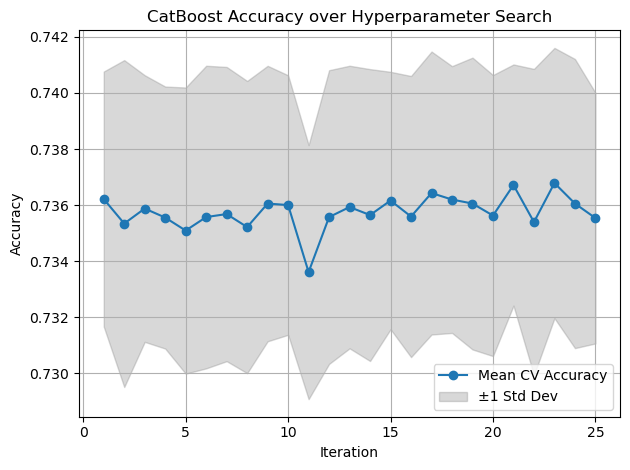


Tuning Neural Network (Model 4)...
Fitting 10 folds for each of 20 candidates, totalling 200 fits

Neural Network (Model 4) - Best Hyperparameters:
{'model__learning_rate': 0.0003, 'model__hidden2': 64, 'model__hidden1': 128, 'model__dropout': 0.2, 'epochs': 60, 'callbacks': <keras.src.callbacks.early_stopping.EarlyStopping object at 0x0000025034C31CA0>, 'batch_size': 128}
Test Set Recall: 0.7832
[[4565 2439]
 [1517 5479]]
              precision    recall  f1-score   support

           0      0.751     0.652     0.698      7004
           1      0.692     0.783     0.735      6996

    accuracy                          0.717     14000
   macro avg      0.721     0.717     0.716     14000
weighted avg      0.721     0.717     0.716     14000


Neural Network (Model 4) CV Mean Accuracy: 0.7326, Std Dev: 0.0005


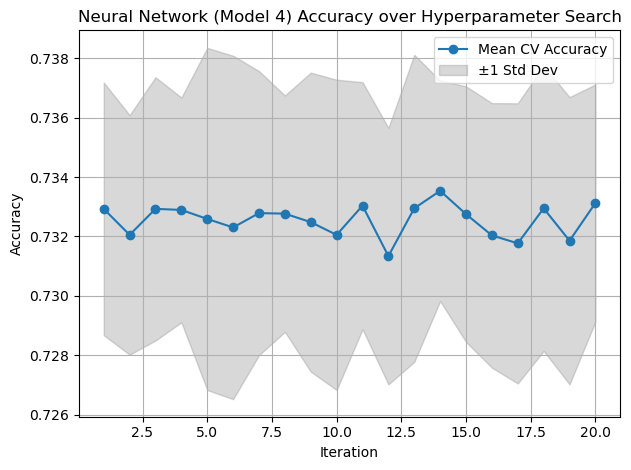

In [275]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import recall_score, confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import uniform
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Cross-validation strategy ---
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# --- Logistic Regression Tuning ---
lr_params = {
    'C': uniform(0.01, 5),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200, 300]
}
lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=lr_params,
    n_iter=20,
    scoring='accuracy',
    cv=cv_strategy,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# --- Random Forest Tuning ---
rf_params = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [8, 10, 12, 14, 16],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    scoring='accuracy',
    cv=cv_strategy,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# --- CatBoost Tuning ---
cat_search = RandomizedSearchCV(
    CatBoostClassifier(random_state=42, verbose=0, early_stopping_rounds=30),
    param_distributions={
        'iterations': [300, 400, 500],
        'depth': [4, 6, 8],
        'learning_rate': uniform(0.01, 0.05),
        'l2_leaf_reg': [3, 5, 7]
    },
    n_iter=25,
    scoring='accuracy',
    cv=cv_strategy,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# --- ANN Model 4 Definition ---
def build_model_4(input_dim, hidden1=128, hidden2=64, dropout=0.2, learning_rate=0.0003):
    model = Sequential([
        Dense(hidden1, activation='tanh', input_shape=(input_dim,)),
        Dropout(dropout),
        Dense(hidden2, activation='tanh'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- Early Stopping Callback ---
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# --- KerasClassifier Wrapper ---
ann = KerasClassifier(model=build_model_4, model__input_dim=x_train.shape[1], verbose=0)

# --- ANN Hyperparameter Grid ---
ann_params = {
    'model__hidden1': [128],         
    'model__hidden2': [64],
    'model__dropout': [0.2],
    'model__learning_rate': [0.0003],

    
    'batch_size': [32, 64, 128, 256],
    'epochs': [30, 40, 50, 60, 80],
    'callbacks': [early_stopping]
}

# --- ANN Randomized Search ---
ann_search = RandomizedSearchCV(
    ann,
    param_distributions=ann_params,
    n_iter=20,
    scoring='accuracy',
    cv=cv_strategy,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

# --- Combine all models ---
search_models = {
    'Logistic Regression': lr_search,
    'Random Forest': rf_search,
    'CatBoost': cat_search,
    'Neural Network (Model 4)': ann_search
}

# --- Fit and Evaluate ---
for name, search in search_models.items():
    print(f"\nTuning {name}...")
    search.fit(x_train, y_train)
    best_model = search.best_estimator_

    if name == 'Neural Network (Model 4)':
        # Threshold 0.4 for ANN predictions
      probs = best_model.predict_proba(x_test)
      preds = (probs[:, 1] > 0.4).astype(int) 
    else:
        preds = best_model.predict(x_test)

    print(f"\n{name} - Best Hyperparameters:\n{search.best_params_}")
    print(f"Test Set Recall: {recall_score(y_test, preds):.4f}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, digits=3))

    cv_scores = search.cv_results_['mean_test_score']
    std_scores = search.cv_results_['std_test_score']

    print(f"\n{name} CV Mean Accuracy: {np.mean(cv_scores):.4f}, Std Dev: {np.std(cv_scores):.4f}")

    # Plotting
    os.makedirs("plots", exist_ok=True)
    plt.figure()
    plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', label='Mean CV Accuracy')
    plt.fill_between(range(1, len(cv_scores) + 1),
                     cv_scores - std_scores, cv_scores + std_scores,
                     color='gray', alpha=0.3, label='±1 Std Dev')
    plt.title(f"{name} Accuracy over Hyperparameter Search")
    plt.xlabel("Iteration")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join("plots", f"{name.replace(' ', '_').lower()}_accuracy.png"))
    plt.show()


Fitting 10 folds for each of 50 candidates, totalling 500 fits
[0]	validation_0-logloss:0.68638
[10]	validation_0-logloss:0.63531
[20]	validation_0-logloss:0.60252
[30]	validation_0-logloss:0.58219
[40]	validation_0-logloss:0.56921
[50]	validation_0-logloss:0.56069
[60]	validation_0-logloss:0.55520
[70]	validation_0-logloss:0.55144
[80]	validation_0-logloss:0.54900
[90]	validation_0-logloss:0.54735
[100]	validation_0-logloss:0.54617
[110]	validation_0-logloss:0.54532
[120]	validation_0-logloss:0.54484
[130]	validation_0-logloss:0.54449
[140]	validation_0-logloss:0.54428
[150]	validation_0-logloss:0.54414
[160]	validation_0-logloss:0.54408
[170]	validation_0-logloss:0.54394
[180]	validation_0-logloss:0.54389
[190]	validation_0-logloss:0.54390
[200]	validation_0-logloss:0.54386
[210]	validation_0-logloss:0.54378
[220]	validation_0-logloss:0.54374
[230]	validation_0-logloss:0.54373
[234]	validation_0-logloss:0.54372

XGBoost - Best Hyperparameters:
{'colsample_bytree': 0.8217416210045603,

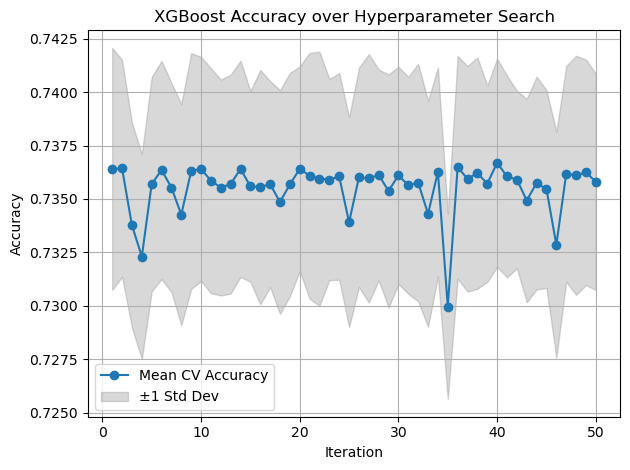

In [126]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

# Cross-Validation strategy
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# hyperparameter ranges
xgb_params = {
    'n_estimators': randint(200, 500),              
    'max_depth': [3, 4, 5, 6],                     
    'learning_rate': uniform(0.005, 0.05),         
    'subsample': uniform(0.6, 0.4),                
    'colsample_bytree': uniform(0.6, 0.4),         
    'gamma': uniform(0.1, 0.9),                     
    'reg_lambda': uniform(1, 9),                   
    'reg_alpha': uniform(0.1, 4.9),                 
    'min_child_weight': randint(1, 10),          
}

# XGBClassifier with early stopping
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False,
        early_stopping_rounds=20,       # early stopping
    ),
    param_distributions=xgb_params,
    n_iter=50,                           
    scoring='accuracy',
    cv=cv_strategy,
    random_state=42,
    verbose=2,                           
    n_jobs=-1
)

#  evaluation set for early stopping
xgb_search.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],  # necessary for early stopping
    verbose=10
)

# Get best model 
best_model = xgb_search.best_estimator_

# Evaluate 
preds = best_model.predict(x_test)
print(f"\nXGBoost - Best Hyperparameters:\n{xgb_search.best_params_}")
print(f"Test Set Recall: {recall_score(y_test, preds):.4f}")
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, digits=3))

cv_scores = xgb_search.cv_results_['mean_test_score']
std_scores = xgb_search.cv_results_['std_test_score']

print(f"\nXGBoost CV Mean Accuracy: {np.mean(cv_scores):.4f}, Std Dev: {np.std(cv_scores):.4f}")

# Plot 
import matplotlib.pyplot as plt
import os
os.makedirs("plots", exist_ok=True)

plt.figure()
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', label='Mean CV Accuracy')
plt.fill_between(
    range(1, len(cv_scores) + 1),
    cv_scores - std_scores, cv_scores + std_scores,
    color='gray', alpha=0.3, label='±1 Std Dev'
)
plt.title("XGBoost Accuracy over Hyperparameter Search")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join("plots", "xgboost_accuracy_final.png"))
plt.show()
